# +--------------------------------------------+
# Name: Muayyad Alnouman.
# ID: 4410286.
# University Email: 4410286
# +---------------------------------------------+


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier #here you need to open terminal and download the xgboost
sns.set(style="whitegrid")

# Scikit-learn models & evaluation
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)




In [5]:
# Load the dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Show the first few rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.isnull().sum()


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
# Drop customerID
df.drop("customerID", axis=1, inplace=True)

# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

# Encode binary columns
cat_cols = df.select_dtypes(include="object").columns
binary_cols = [col for col in cat_cols if df[col].nunique() == 2]
for col in binary_cols:
    df[col] = df[col].replace({"Yes": 1, "No": 0})


C:\Users\muayy\AppData\Local\Temp\ipykernel_18604\3103461125.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)
C:\Users\muayy\AppData\Local\Temp\ipykernel_18604\3103461125.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[c

In [9]:
# Update cat_cols again after binary encoding
cat_cols = df.select_dtypes(include="object").columns

# Apply get_dummies only to actual categoricals
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)


In [10]:
df = df.replace({True: 1, False: 0})


C:\Users\muayy\AppData\Local\Temp\ipykernel_18604\2180546242.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({True: 1, False: 0})


In [11]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7043 non-null   int64  
 1   Partner                                7043 non-null   int64  
 2   Dependents                             7043 non-null   int64  
 3   tenure                                 7043 non-null   int64  
 4   PhoneService                           7043 non-null   int64  
 5   PaperlessBilling                       7043 non-null   int64  
 6   MonthlyCharges                         7043 non-null   float64
 7   TotalCharges                           7043 non-null   float64
 8   Churn                                  7043 non-null   int64  
 9   gender_Male                            7043 non-null   int64  
 10  MultipleLines_No phone service         7043 non-null   int64  
 11  Mult

In [12]:
df[["tenure", "MonthlyCharges", "TotalCharges"]].describe()


,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2281.916928
std,24.559481,30.090047,2265.270398
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,402.225000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


## what i did so far for assignment1:
###### -loaded the dataset and took a walk in it.
###### -i saw its datatypes and colmuns 
###### -i searcher for how many null values there are.
###### -i deleted the customer id since it wont help with any training 
###### -i convert the total charge to numeric values
###### -for the binary things i made a 0/1 insted of T/F so it can be a numiric things

# ==============================================

# Assignment 2 Exploratory Data Analysis (EDA):

### Visualize churn rates across demographics (gender, senior citizen, partner, dependents).



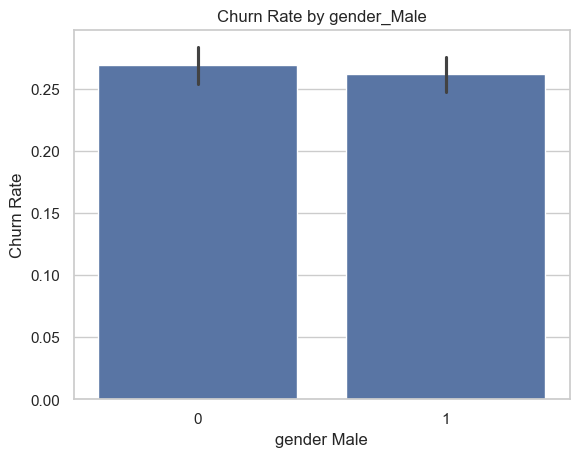

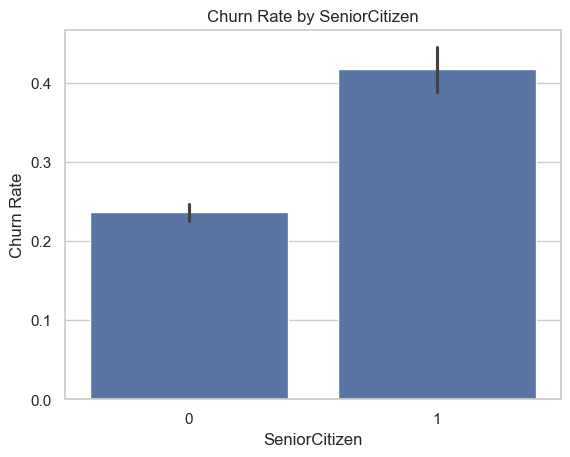

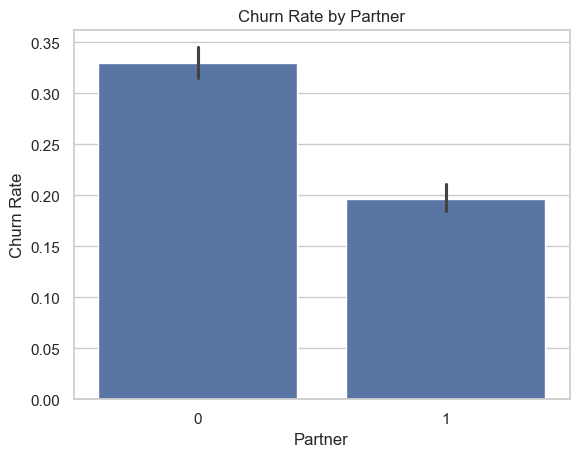

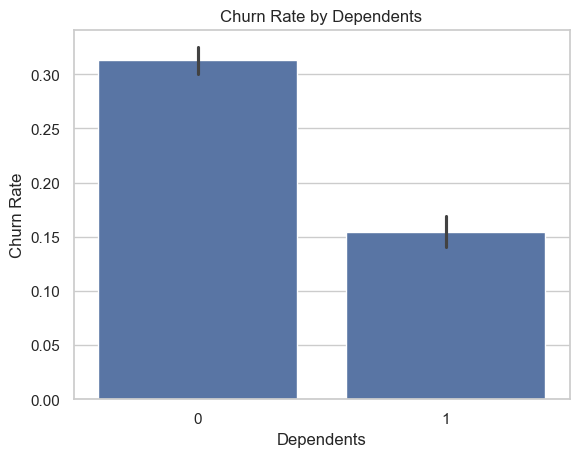

In [13]:
sns.set(style="whitegrid")

# Plot churn rates across demographics
demographics = ["gender_Male", "SeniorCitizen", "Partner", "Dependents"]
#note: there is only gender_male col becase i applied one-hot encoding earlier with drop_first=True, which removed the Female
#gender_male = 0 then femal
#gender_male = 1 then male
for col in demographics:
    sns.barplot(x=df[col], y=df["Churn"])
    plt.title(f"Churn Rate by {col}")
    plt.ylabel("Churn Rate")
    plt.xlabel(col.replace("_", " "))
    plt.show()

### Explainantion:
*first remember im trying to predict who will leave. and (why) they would leave?*
* 1-Churn Rate by gender_Male: Both genders have a very similar churn rate. Conclusion: gender doesnt strongly affect whether someone will leave.
* 2-Churn Rate by SeniorCitizen: Compares non-seniors (0) and seniors (1).  Senior citizens churn more than non-seniors. Conclusion: Older customers are more likely to cancel service.
* 3- Churn Rate by Partner: Compares customers without a partner (0) and with a partner (1).Those without partners churn more than those with partners.Conclusion: Having a partner may be linked to more account stability.
* 4-Churn Rate by Dependents: Compares customers without dependents (0) and with dependents (1).Those without dependents churn more than those with dependents. Conclusion: Customers with families/dependents are more loyal.






##### 2-Analyze churn in relation to services (InternetService, TechSupport, OnlineSecurity).



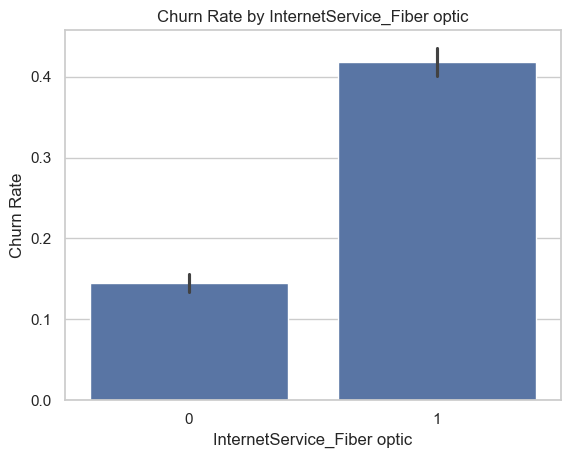

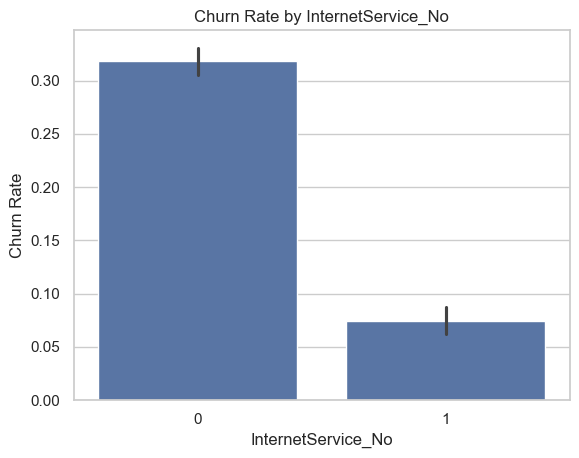

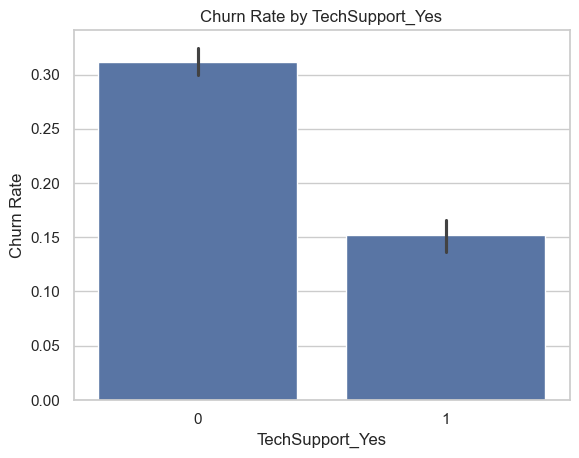

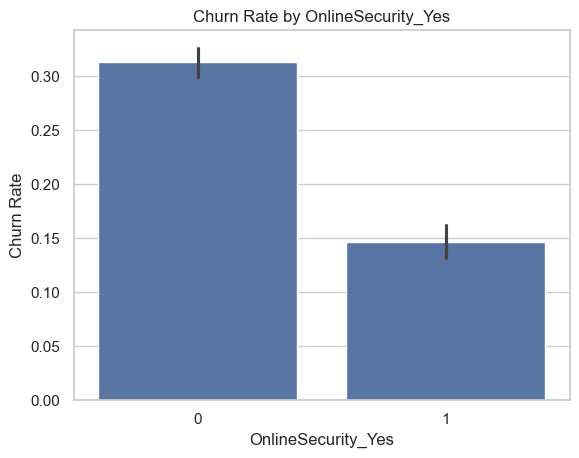

In [14]:
service_cols = [
    "InternetService_Fiber optic", 
    "InternetService_No", 
    "TechSupport_Yes", 
    "OnlineSecurity_Yes"
]

for col in service_cols:
    sns.barplot(x=df[col], y=df["Churn"])
    plt.title(f"Churn Rate by {col}")
    plt.ylabel("Churn Rate")
    plt.xlabel(col)
    plt.show()

### Explainantion:
* 1-Churn Rate by InternetService_Fiber optic: Compares non–fiber optic users (0) to fiber optic users (1).  Fiber users churn more than non-fiber users. Conclusion: Fiber optic customers may be unhappy with the service or pricing.
* 2-Churn Rate by InternetService_No: People without internet churn less.  Conclusion: Internet users churn more, maybe due to issues with service or cost.
* 3-Churn Rate by TechSupport_Yes: Compares customers without tech support (0) and with tech support (1). Customers with support churn less than those without. Conclusion: Providing tech support may help reduce churn.
* 4-Churn Rate by OnlineSecurity_Yes: Compares customers without online security (0) and with it (1).  Security users churn less than non-users. Conclusion: Security services improve retention.



##### 3-Use bar charts and boxplots to study churn vs. tenure, monthly charges, and contract type.


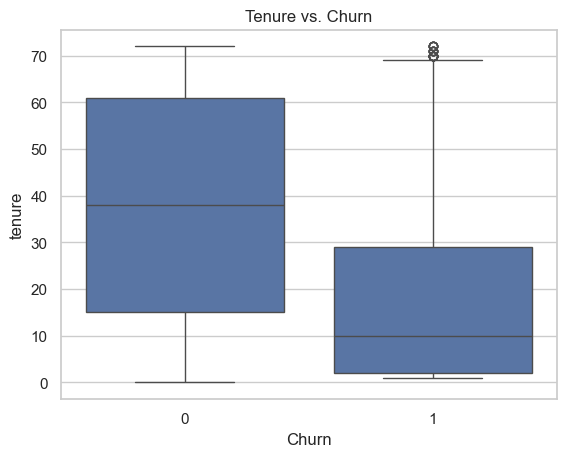

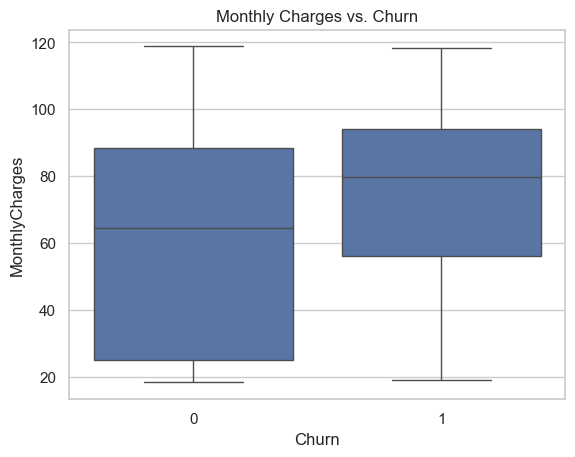

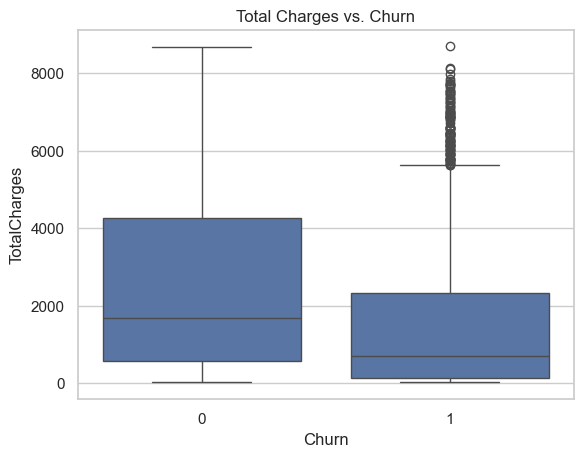

In [15]:
sns.boxplot(x=df["Churn"], y=df["tenure"])
plt.title("Tenure vs. Churn")
plt.show()

sns.boxplot(x=df["Churn"], y=df["MonthlyCharges"])
plt.title("Monthly Charges vs. Churn")
plt.show()

sns.boxplot(x=df["Churn"], y=df["TotalCharges"])
plt.title("Total Charges vs. Churn")
plt.show()


### Explainantion of Boxplots:
* 1-Tenure vs. Churn: Shows how long customers stayed (in months). Churned customers (1) have shorter tenure, mostly under 20 months. Conclusion: Newer customers are more likely to leave early.
* 2-MonthlyCharges vs. Churn: Shows monthly bill amounts. Churned customers (1) tend to have higher bills. Conclusion: Higher cost might push customers to cancel.
* 3-TotalCharges vs. Churn: Shows total money paid by the customer. Churned customers have much lower total charges. Conclusion: They left early and didn’t stay long enough to accumulate charges.

##### 4-Identify top 5 variables you believe most influence customer churn.

Top 5 Influential Features:
TotalCharges                      0.199724
MonthlyCharges                    0.172154
tenure                            0.169151
InternetService_Fiber optic       0.039605
PaymentMethod_Electronic check    0.038754
dtype: float64


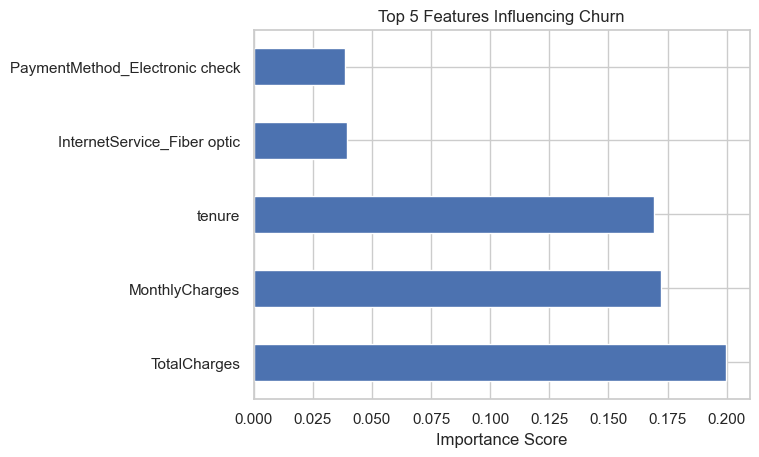

In [16]:
# Define features and target
X = df.drop("Churn", axis=1)
y = df["Churn"]

# Fit model
rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)

# Feature importances
importances = pd.Series(rf.feature_importances_, index=X.columns)
top_5 = importances.sort_values(ascending=False).head(5)
print("Top 5 Influential Features:")
print(top_5)

# Plot
top_5.plot(kind='barh')
plt.title("Top 5 Features Influencing Churn")
plt.xlabel("Importance Score")
plt.show()

## Summary 3 key insights with potential business impact.


* 1- Customers with fiber optic internet show significantly higher churn rates compared to DSL or no internet service
* 2- we can do more advirtisement on customers that have families since they churn less.
* 3- we need to improve the internet user support since there are a lot who churn because there is no or little support.


# ==============================================

.

# Assignment 3 Churn Prediction Modeling


### Objective Build a machine learning model to predict whether a customer will churn.


In [17]:
# Features and target
#Split the Dataset (Stratified Sampling)
X = df.drop("Churn", axis=1)
y = df["Churn"]

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [18]:
#Train Models

#Logistic Regression
lr_model = LogisticRegression(max_iter=100000)
lr_model.fit(X_train, y_train)


LogisticRegression(max_iter=100000)

In [19]:
#RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    random_state=42
)
rf_model.fit(X_train, y_train)


RandomForestClassifier(max_depth=10, min_samples_split=10, n_estimators=200,
                       random_state=42)

In [20]:
#XGBoost
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)

C:\Users\muayy\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:38:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [21]:
#reusable function for reporting:

def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    print(f"--- {name} ---")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1-score:", f1_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} – Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # ROC curve
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.title(f"{name} – ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.grid()
    plt.show()


--- Logistic Regression ---
Accuracy: 0.8062455642299503
Precision: 0.6593059936908517
Recall: 0.5588235294117647
F1-score: 0.6049204052098408

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.90      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



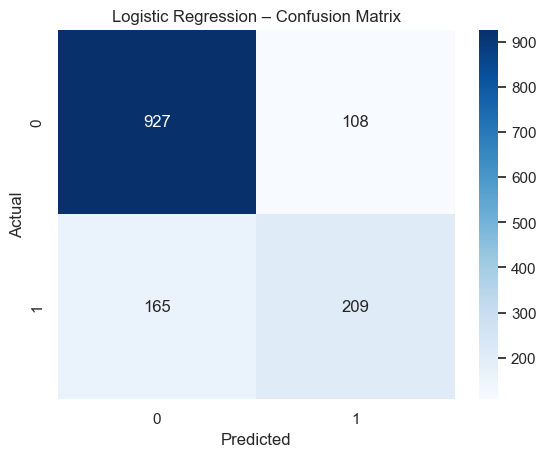

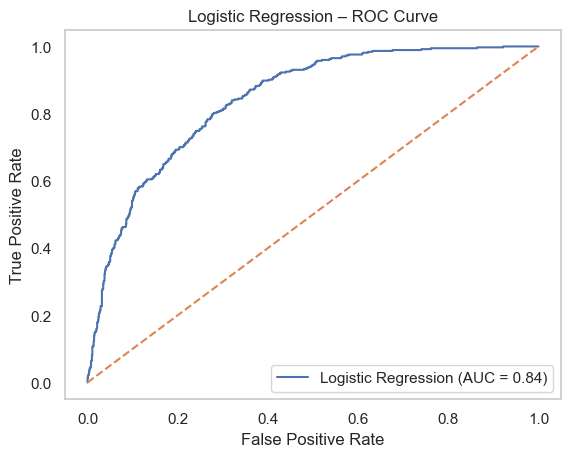

--- Random Forest (Tuned) ---
Accuracy: 0.8026969481902059
Precision: 0.6666666666666666
Recall: 0.5133689839572193
F1-score: 0.5800604229607251

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.51      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



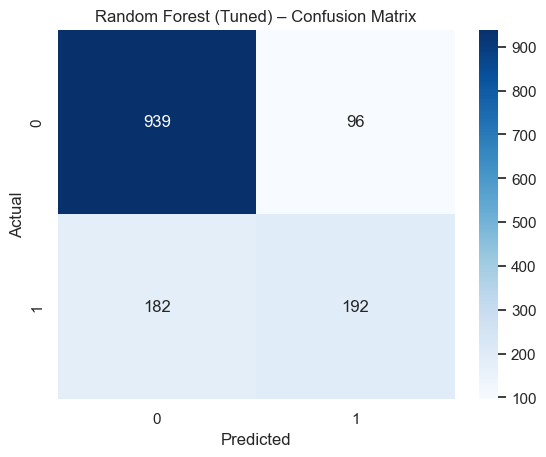

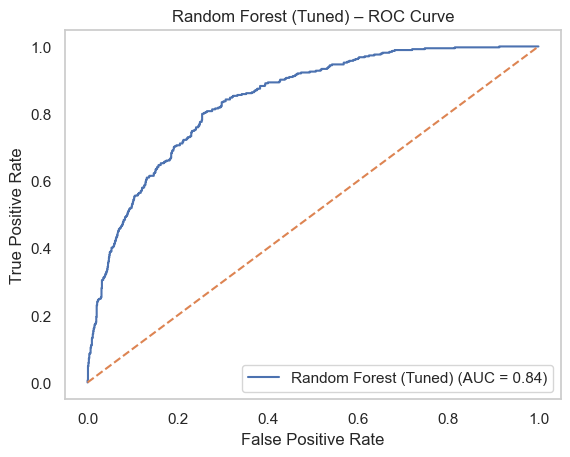

--- XGBoost ---
Accuracy: 0.7856635911994322
Precision: 0.6090909090909091
Recall: 0.5374331550802139
F1-score: 0.5710227272727273

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.88      0.86      1035
           1       0.61      0.54      0.57       374

    accuracy                           0.79      1409
   macro avg       0.72      0.71      0.71      1409
weighted avg       0.78      0.79      0.78      1409



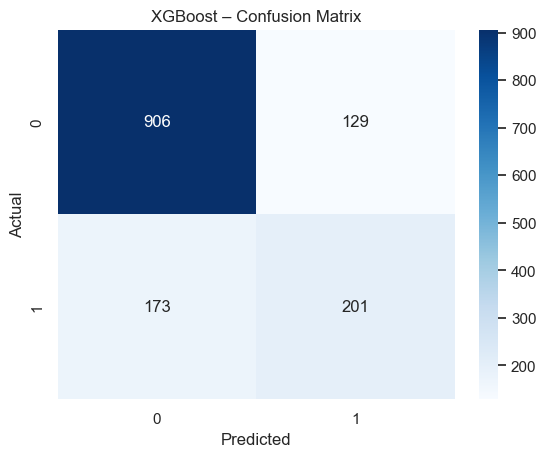

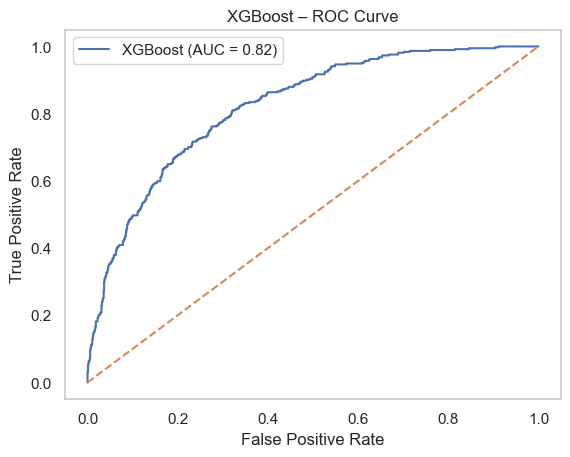

In [22]:
evaluate_model("Logistic Regression", lr_model, X_test, y_test)
evaluate_model("Random Forest (Tuned)", rf_model, X_test, y_test)
evaluate_model("XGBoost", xgb_model, X_test, y_test)

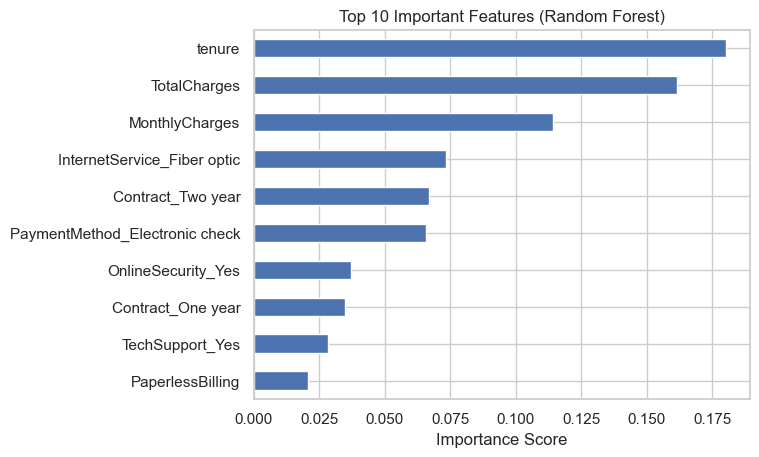

In [23]:
# Feature importance
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

# Top 10
importances.head(10).plot(kind='barh')
plt.title("Top 10 Important Features (Random Forest)")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.show()






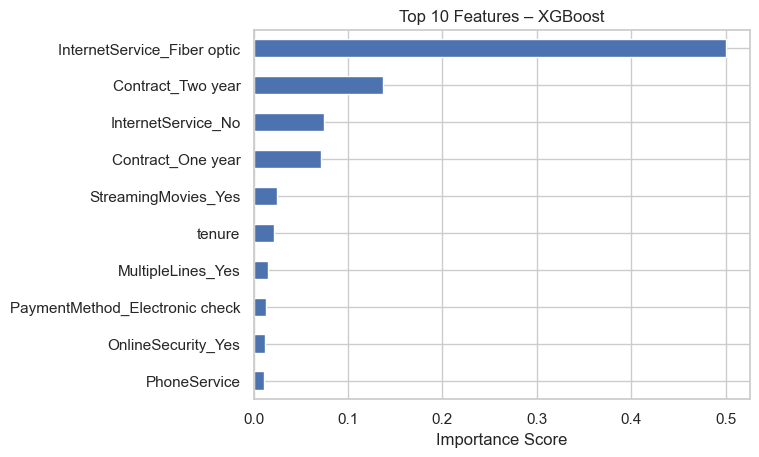

In [24]:
# Feature importance from XGBoost
importances = pd.Series(xgb_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

# Plot top 10
importances.head(10).plot(kind='barh')
plt.title("Top 10 Features – XGBoost")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.show()

## *Who i would recommend between (Logistic Regression) VS (Random Forest Classifier) VS (XGBoost)?*

### ((Logistic Regression)) wins overall, especially in Recall and F1-score, Why?? see Comparison Table: 



#### Comparison:
	Logistic Regression:
        * Accuracy: 0.8062455642299503
        * Precision: 0.6593059936908517
        * Recall: 0.5588235294117647
        * F1-score: 0.6049204052098408

        -----------------------------------------
        
    Random Forest (Tuned)
        *Accuracy: 0.8026969481902059
        *Precision: 0.6666666666666666
        *Recall: 0.5133689839572193
        *F1-score: 0.5800604229607251

        -----------------------------------------
    XGBoost
        *Accuracy: 0.7856635911994322
        *Precision: 0.6090909090909091
        *Recall: 0.5374331550802139
        *F1-score: 0.5710227272727273
        


## References
####  ChatGPT-4o extensively to help me deep understand this project:
* How to implement and evaluate machine learning models step by step
* Understanding key performance metrics like precision, recall, and F1-score
* Learn how to use Jupyter Notebooks, which was a new tool for me
* Debugging and interpreting results across Logistic Regression, Random Forest, and XGBoost

### Helpful resources I saw:

* Changing the random state for the data split results in a changed AUC for my Random Forest model (StackExchange) https://stats.stackexchange.com/questions/554599/changing-the-random-state-for-the-data-split-results-in-a-changed-auc-for-my-ran

* YouTube Short: Random State in Machine Learning: https://www.youtube.com/shorts/nrkAcU3srwQ